# A* 알고리즘으로 강 건너기

상태는 `(농부, 늑대, 염소, 양배추)` 순서의 4비트로 표현합니다.

- `0`: 왼쪽 강변
- `1`: 오른쪽 강변
- 초기 상태: `0000`
- 목표 상태: `1111`

한 번에 농부 혼자 또는 농부와 같은 강변에 있는 동물/양배추 하나가 함께 이동할 수 있습니다. 농부가 없는 곳에서 늑대와 염소가 함께 있거나, 염소와 양배추가 함께 있으면 위험한 상태입니다.

In [13]:
import heapq
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch

START = (0, 0, 0, 0)
GOAL = (1, 1, 1, 1)
NAMES = ("농부", "늑대", "염소", "양배추")
CODES = ("F", "W", "G", "C")


def state_text(state):
    return "".join(map(str, state))


def unsafe_reasons(state):
    farmer, wolf, goat, cabbage = state
    reasons = []
    if wolf == goat and farmer != wolf:
        reasons.append("늑대가 염소를 먹음")
    if goat == cabbage and farmer != goat:
        reasons.append("염소가 양배추를 먹음")
    return reasons


def is_safe(state):
    return not unsafe_reasons(state)

## 1. 전체 16개 상태 확인

가능한 모든 4비트 상태를 검사해 안전 여부와 위험한 이유를 확인합니다.

In [14]:
all_states = list(product((0, 1), repeat=4))
safe_states = []

print("상태   판정   이유")
print("-" * 45)
for state in all_states:
    reasons = unsafe_reasons(state)
    if reasons:
        print(f"{state_text(state)}   위험   {', '.join(reasons)}")
    else:
        safe_states.append(state)
        print(f"{state_text(state)}   안전   -")

print(f"\n안전한 상태: {len(safe_states)}개 / 전체 {len(all_states)}개")

상태   판정   이유
---------------------------------------------
0000   안전   -
0001   안전   -
0010   안전   -
0011   위험   염소가 양배추를 먹음
0100   안전   -
0101   안전   -
0110   위험   늑대가 염소를 먹음
0111   위험   늑대가 염소를 먹음, 염소가 양배추를 먹음
1000   위험   늑대가 염소를 먹음, 염소가 양배추를 먹음
1001   위험   늑대가 염소를 먹음
1010   안전   -
1011   안전   -
1100   위험   염소가 양배추를 먹음
1101   안전   -
1110   안전   -
1111   안전   -

안전한 상태: 10개 / 전체 16개


## 2. 이동 규칙과 평가 함수

A*의 평가 함수는 `f(n) = g(n) + h(n)`입니다.

- `g(n)`: 지금까지 배를 이동한 횟수
- `h(n)`: 아직 왼쪽에 남아 있는 늑대, 염소, 양배추의 수

남아 있는 각 대상은 적어도 한 번 오른쪽으로 이동해야 하므로 이 휴리스틱은 실제 남은 비용을 초과하지 않습니다.

In [15]:
def heuristic(state):
    return sum(value == 0 for value in state[1:])


def successors(state):
    farmer_side = state[0]
    passengers = [None]
    passengers.extend(
        index for index in range(1, 4) if state[index] == farmer_side
    )

    result = []
    for passenger in passengers:
        next_state = list(state)
        next_state[0] = 1 - next_state[0]
        if passenger is not None:
            next_state[passenger] = 1 - next_state[passenger]
        next_state = tuple(next_state)

        direction = "->" if next_state[0] == 1 else "<-"
        if passenger is None:
            description = f"농부 혼자 {direction}"
            short_label = f"F {direction}"
        else:
            description = f"농부와 {NAMES[passenger]} {direction}"
            short_label = f"F+{CODES[passenger]} {direction}"
        result.append(
            (next_state, description, short_label, unsafe_reasons(next_state))
        )

    return result

## 3. A* 탐색과 단계 기록

각 반복에서 현재 노드의 가능한 다음 상태를 모두 평가합니다. 위험한 상태도 버리지 않고 `DANGER/CLOSED`로 기록하며, 각 단계의 OPEN/CURRENT/NEXT/CLOSED 집합과 발견 트리를 스냅샷으로 저장합니다.

In [16]:
def astar(start, goal, on_step=None):
    counter = 0
    open_heap = [(heuristic(start), heuristic(start), counter, start)]
    open_nodes = {start}
    closed_nodes = set()
    g_score = {start: 0}
    parent = {start: None}
    parent_action = {}
    parent_edge_label = {}
    danger_edges = []
    snapshots = []

    def discard_stale_entries():
        while open_heap:
            f_value, _, _, state = open_heap[0]
            expected_f = g_score.get(state, float("inf")) + heuristic(state)
            if state in open_nodes and f_value == expected_f:
                break
            heapq.heappop(open_heap)

    step = 0
    while open_heap:
        discard_stale_entries()
        if not open_heap:
            break

        _, _, _, current = heapq.heappop(open_heap)
        open_nodes.remove(current)
        step += 1
        candidate_rows = []
        new_open_nodes = set()
        new_danger_nodes = set()

        if current != goal:
            for next_state, action, edge_label, danger_reasons in successors(current):
                tentative_g = g_score[current] + 1
                h_value = heuristic(next_state)
                f_value = tentative_g + h_value

                if danger_reasons:
                    result = "DANGER / CLOSED"
                    danger_is_new = not any(
                        target == next_state for _, target, _ in danger_edges
                    )
                    if danger_is_new:
                        danger_edges.append((current, next_state, edge_label))
                        new_danger_nodes.add(next_state)
                elif next_state in closed_nodes:
                    result = "CLOSED"
                elif tentative_g < g_score.get(next_state, float("inf")):
                    is_new = next_state not in g_score
                    g_score[next_state] = tentative_g
                    parent[next_state] = current
                    parent_action[next_state] = action
                    parent_edge_label[next_state] = edge_label
                    counter += 1
                    heapq.heappush(
                        open_heap, (f_value, h_value, counter, next_state)
                    )
                    open_nodes.add(next_state)
                    if is_new:
                        new_open_nodes.add(next_state)
                    result = "ADD" if is_new else "UPDATE"
                else:
                    result = "KEEP"

                candidate_rows.append(
                    {
                        "state": next_state,
                        "move": edge_label,
                        "g": tentative_g,
                        "h": h_value,
                        "f": f_value,
                        "result": result,
                    }
                )

        closed_nodes.add(current)
        discard_stale_entries()
        next_node = open_heap[0][3] if open_heap and current != goal else None

        for row in candidate_rows:
            if row["state"] == next_node:
                row["result"] += " / NEXT"

        open_candidates = []
        for state in sorted(
            open_nodes,
            key=lambda node: (g_score[node] + heuristic(node), heuristic(node), node),
        ):
            open_candidates.append(
                {
                    "state": state,
                    "g": g_score[state],
                    "h": heuristic(state),
                    "f": g_score[state] + heuristic(state),
                    "selected": state == next_node,
                }
            )

        tree_edges = [
            (previous, state, parent_edge_label[state])
            for state, previous in parent.items()
            if previous is not None
        ]
        snapshot = {
                "step": step,
                "current": current,
                "next": next_node,
                "open": set(open_nodes),
                "closed": set(closed_nodes),
                "new_open": new_open_nodes,
                "new_danger": new_danger_nodes,
                "candidates": candidate_rows,
                "open_candidates": open_candidates,
                "tree_edges": tree_edges,
                "danger_edges": list(danger_edges),
                "g_score": dict(g_score),
        }
        snapshots.append(snapshot)
        if on_step is not None:
            on_step(snapshot)

        if current == goal:
            path = []
            node = goal
            while node is not None:
                path.append(node)
                node = parent[node]
            path.reverse()
            return path, parent_action, parent, parent_edge_label, snapshots

    return None, parent_action, parent, parent_edge_label, snapshots

## 4. 최단 경로 출력 함수

탐색이 끝나면 이동 전 상태, 이동 방법, 이동 후 상태를 순서대로 출력합니다.

In [17]:
def print_solution(path, actions):
    print(f"시작: {state_text(path[0])}")
    for move_number, state in enumerate(path[1:], start=1):
        previous = path[move_number - 1]
        print(
            f"{move_number}. {state_text(previous)} -- "
            f"{actions[state]} --> {state_text(state)}"
        )
    print(f"도착: {state_text(path[-1])}")

## 5. 모든 탐색 단계 시각화

A*가 노드 하나를 확장할 때마다 즉시 한 개의 그림을 출력합니다. 왼쪽에는 그때까지 발견한 탐색 트리, 오른쪽에는 현재 상태에서 검사한 다음 상태 후보를 표시합니다.

- 흰색 `OPEN`: 이전 단계에서 열렸고 아직 탐색하지 않은 노드
- 초록 `CURRENT`: 현재 탐색하는 노드
- 파랑 `NEW OPEN`: 이번 탐색에서 새롭게 열린 노드
- 빨강 `NEW DANGER`: 이번 탐색에서 새롭게 발견한 위험 노드
- 회색 `CLOSED`: 닫힌 노드와 이전 탐색에서 발견한 위험 노드
- 후보 표의 `ADD`, `UPDATE`, `KEEP`, `CLOSED`, `DANGER/CLOSED`, `NEXT`는 각각 OPEN 추가, 비용 개선, 기존 경로 유지, 이미 탐색 완료, 위험 상태 제외, 다음 선택을 뜻합니다.
- 평가 함수는 `g + h = f` 형식의 한 열로 표시합니다.

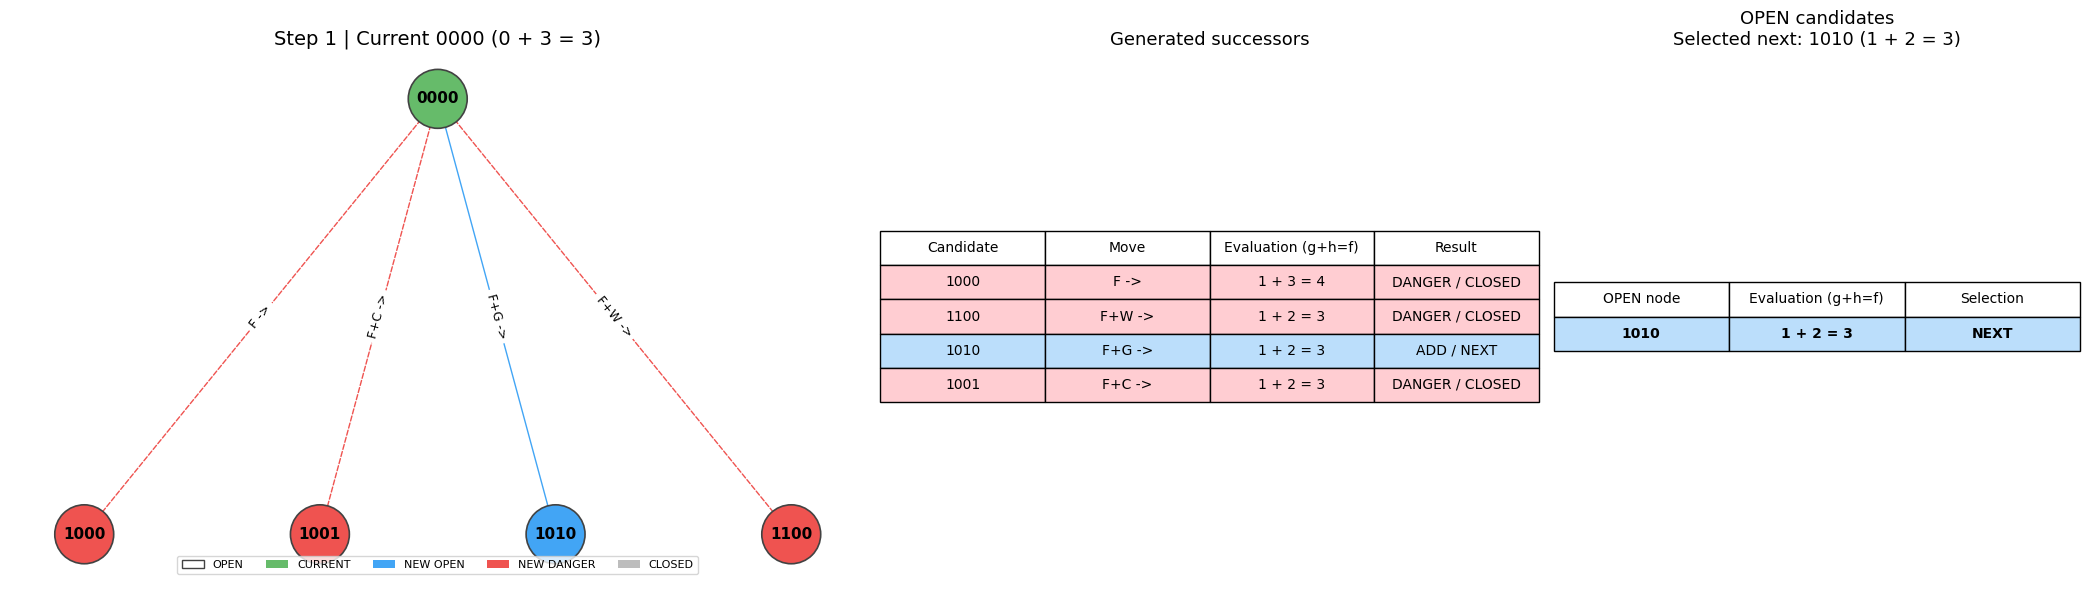

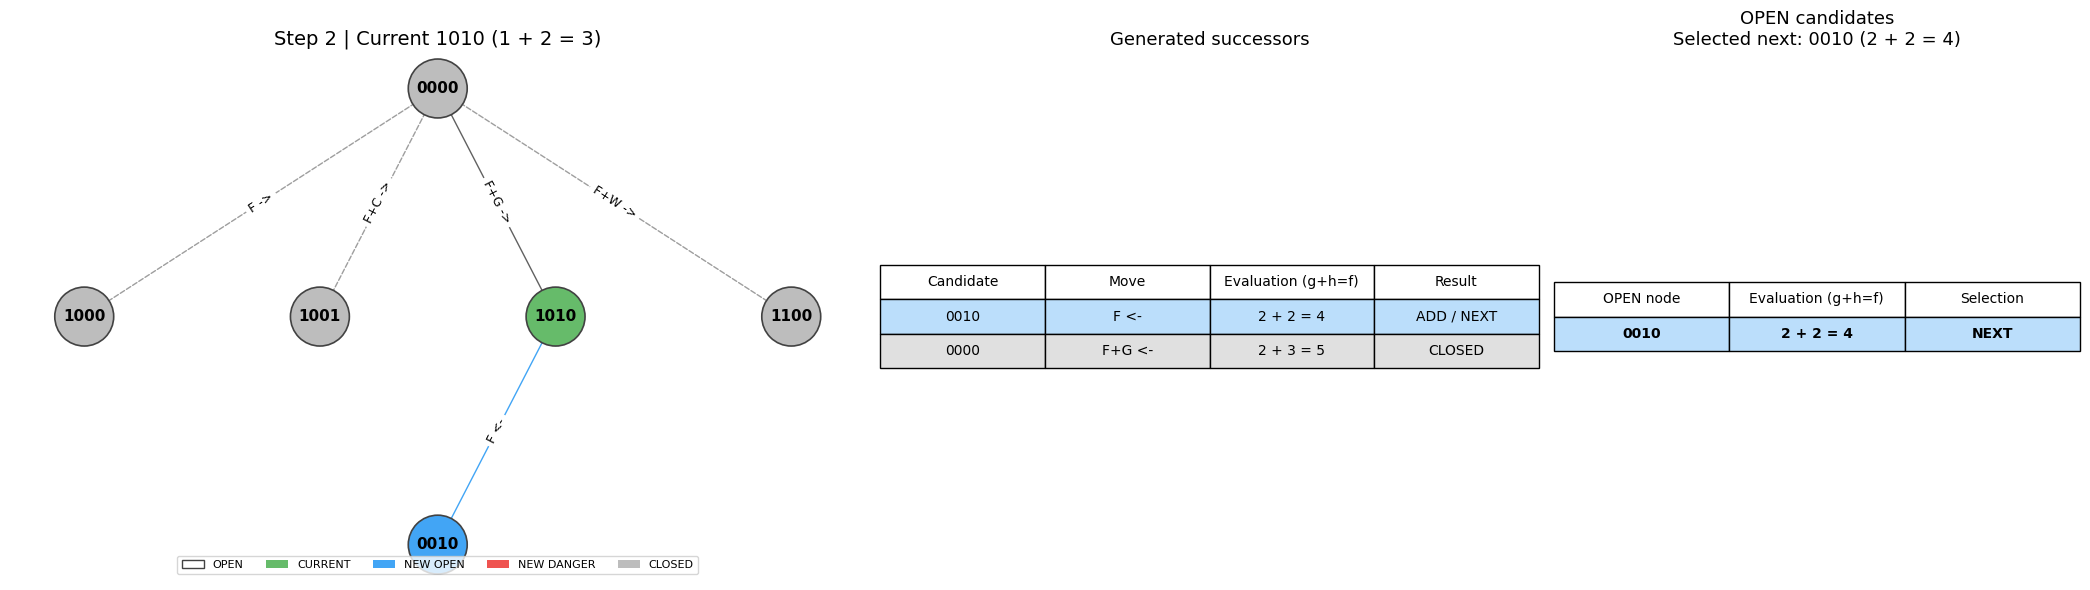

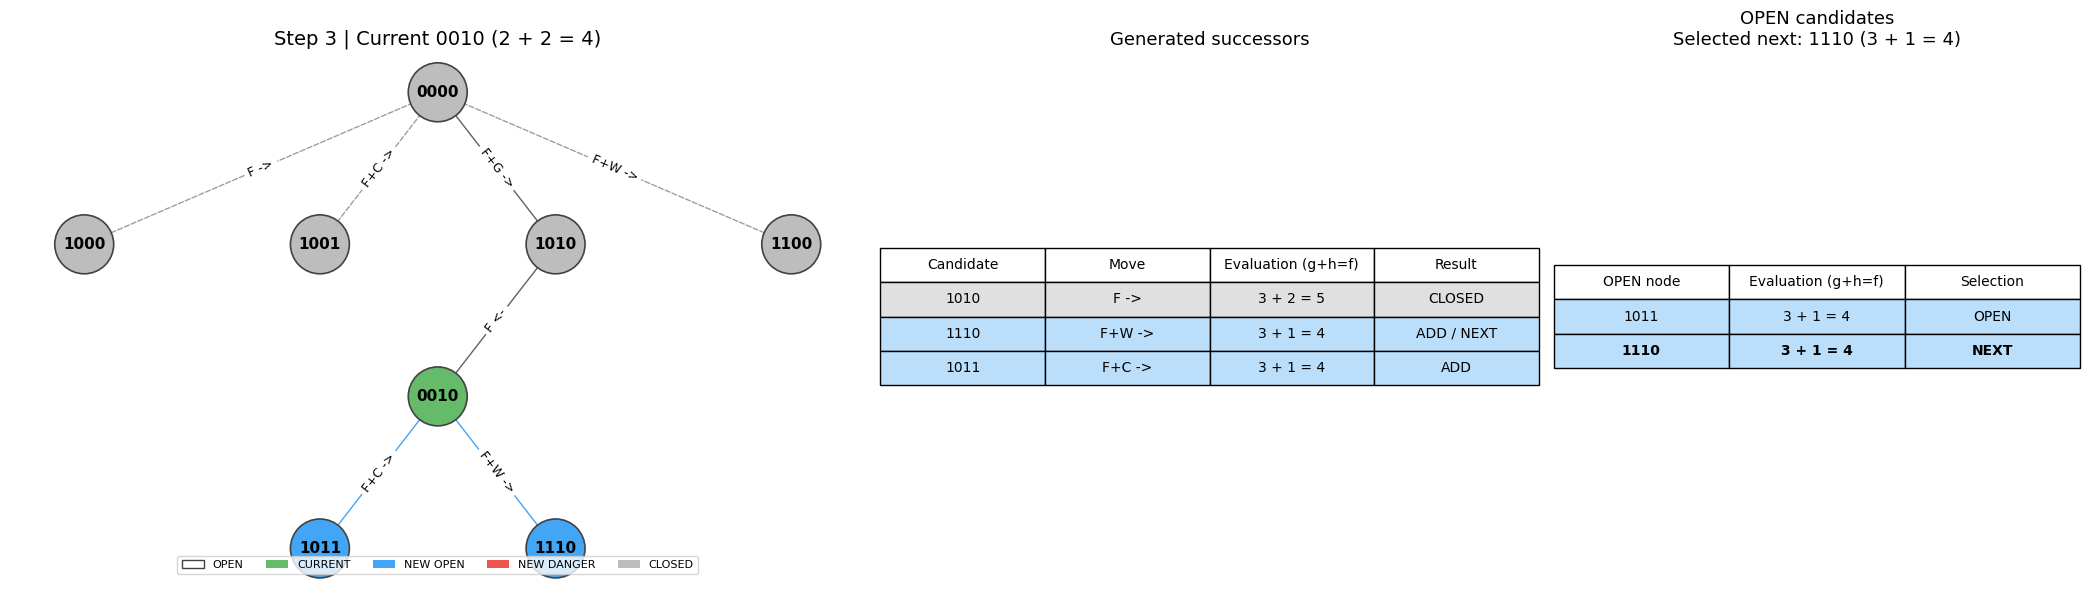

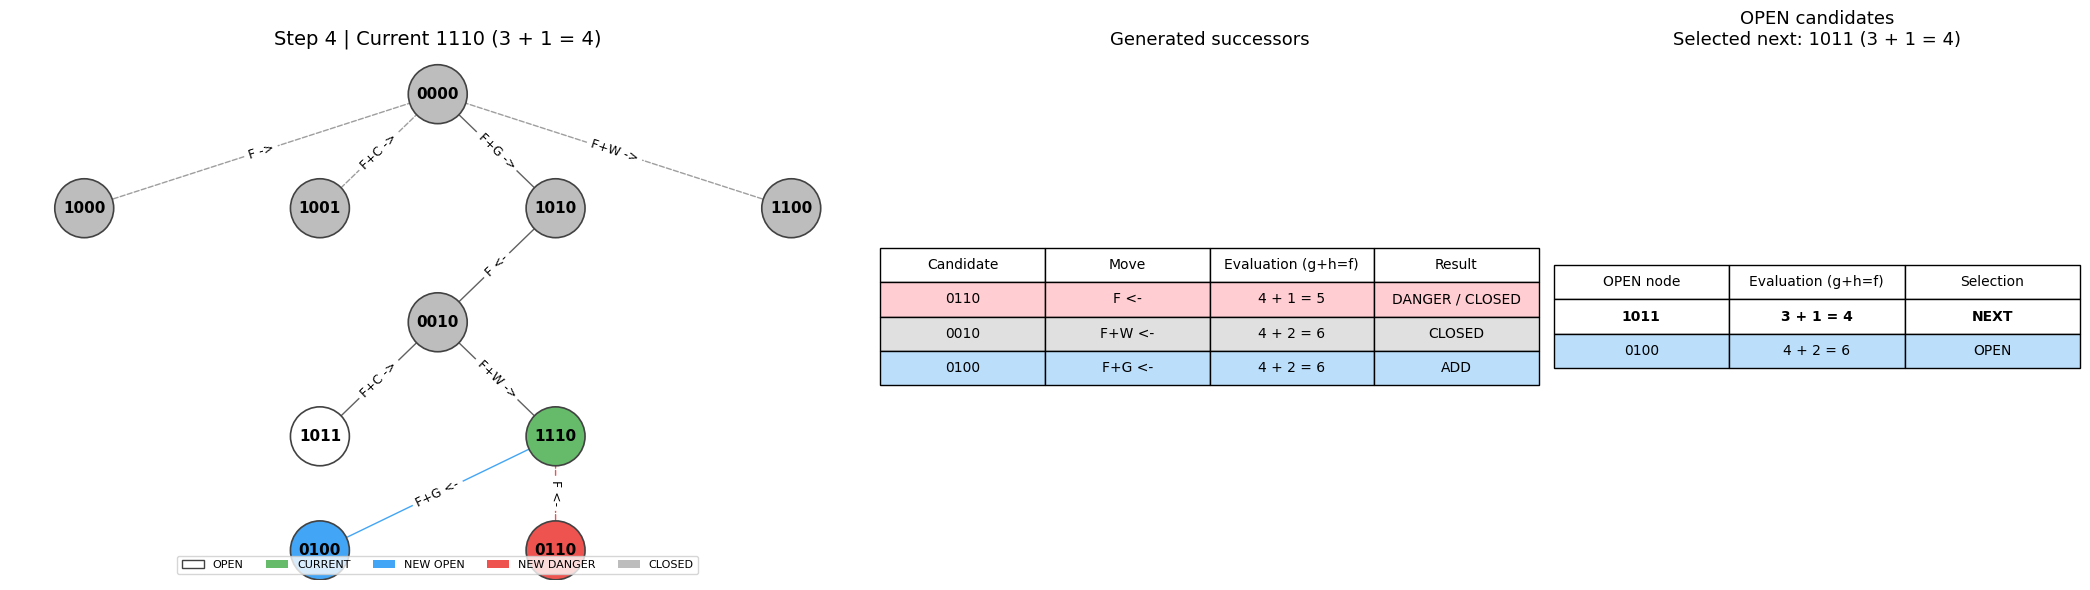

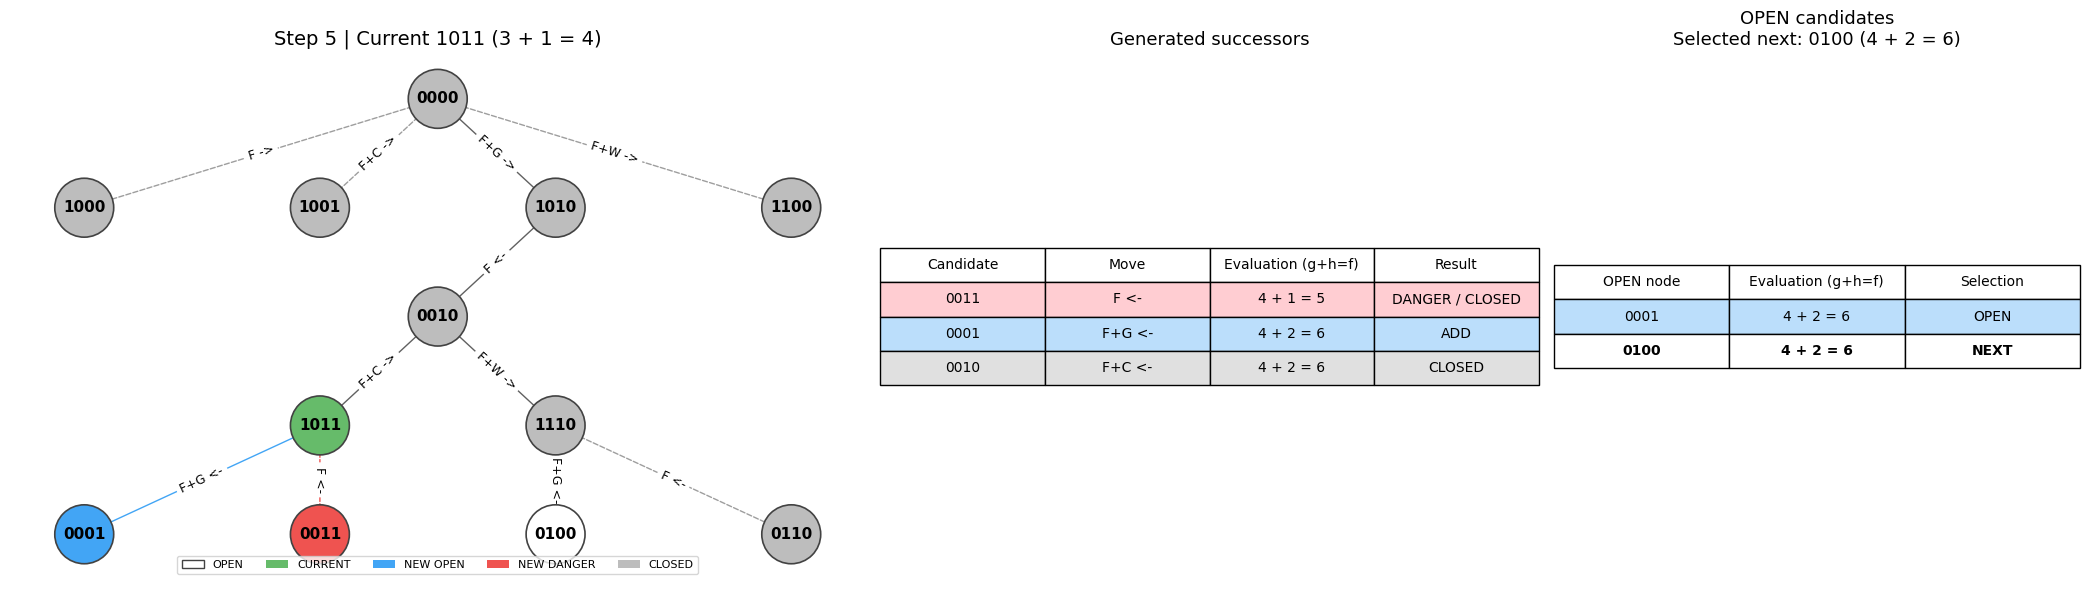

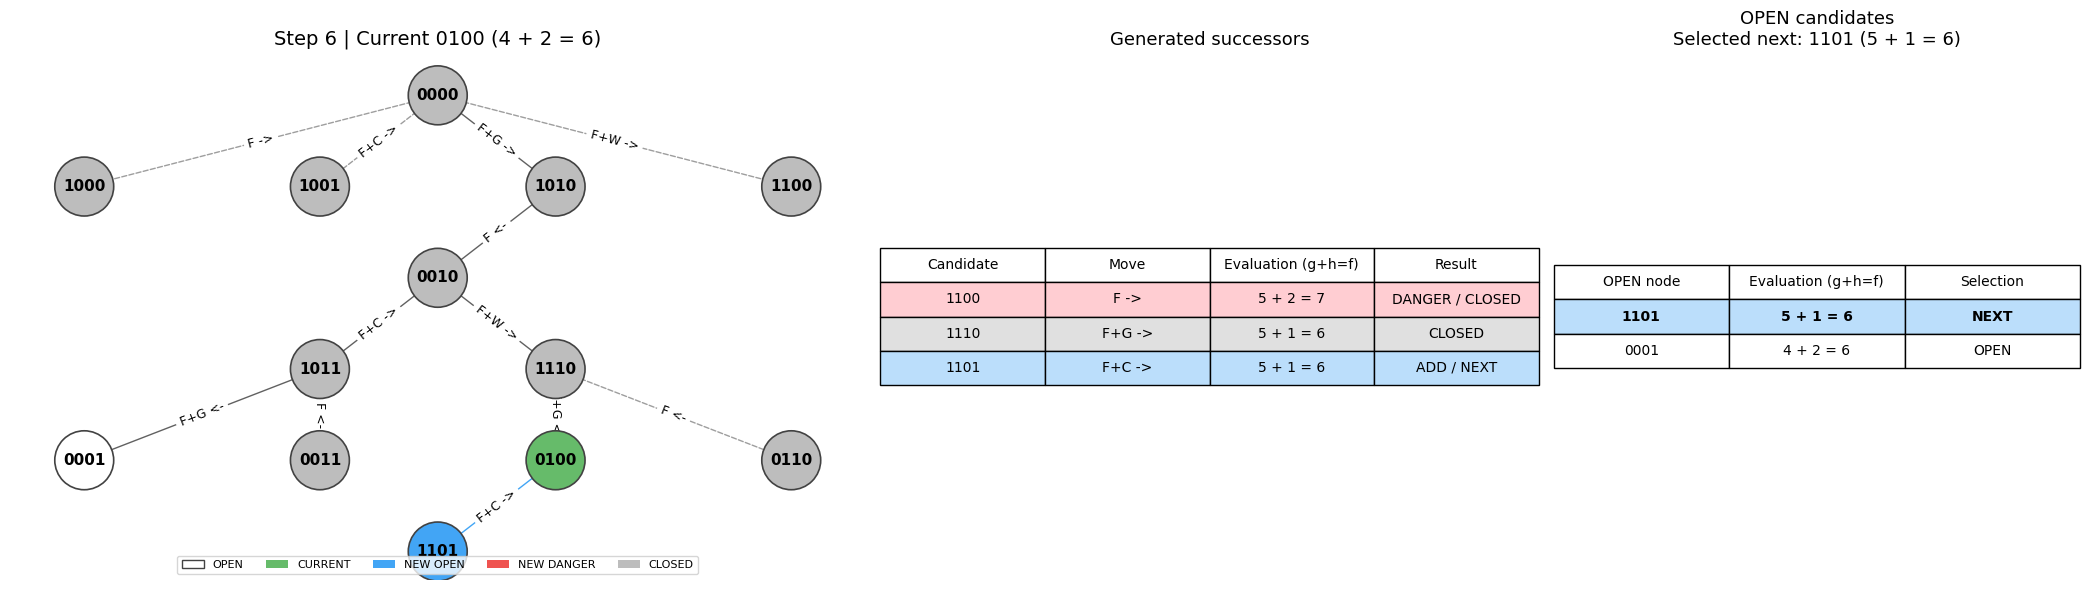

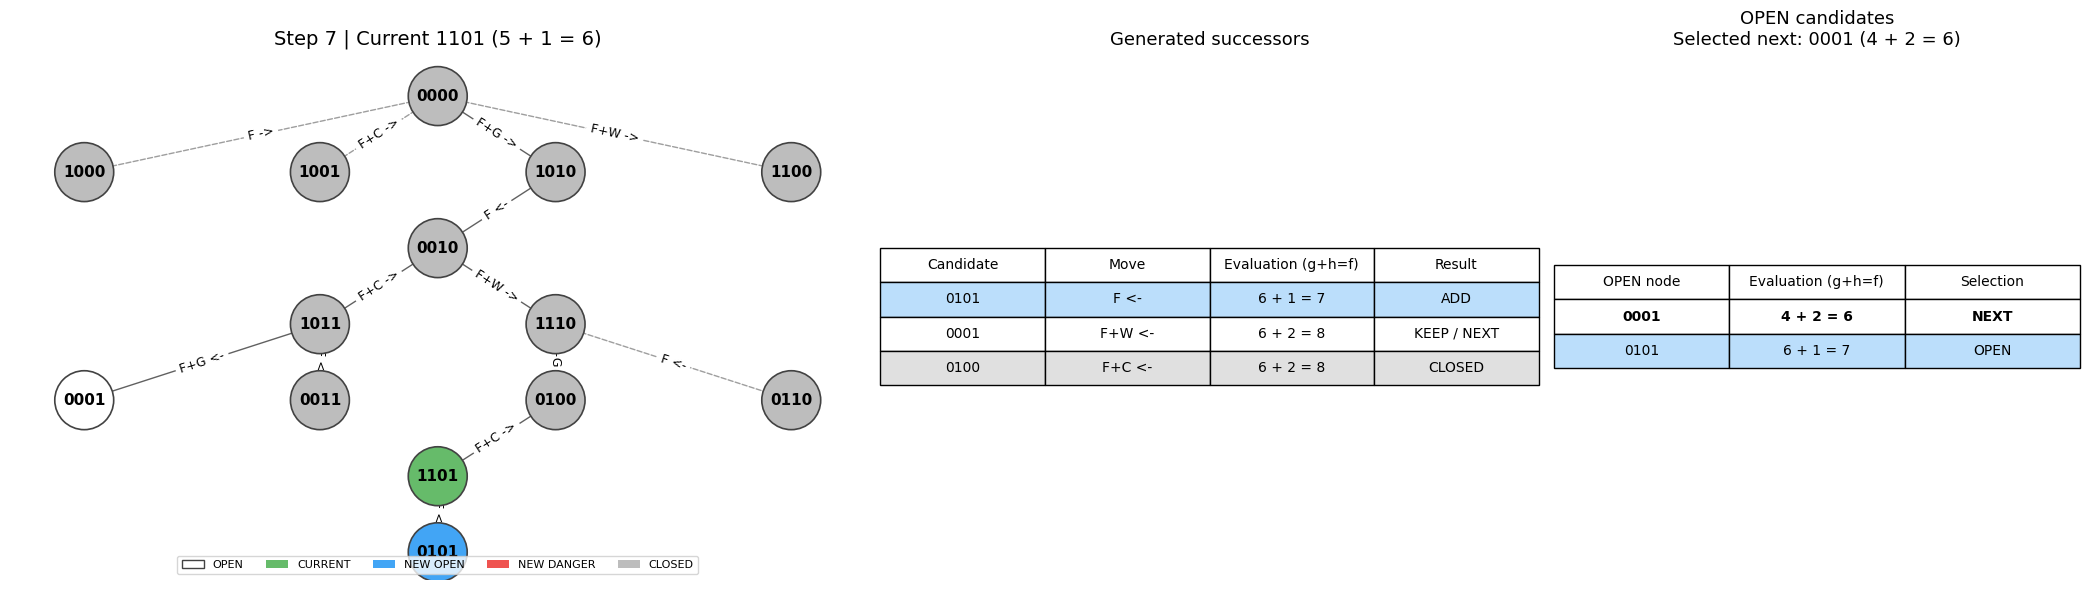

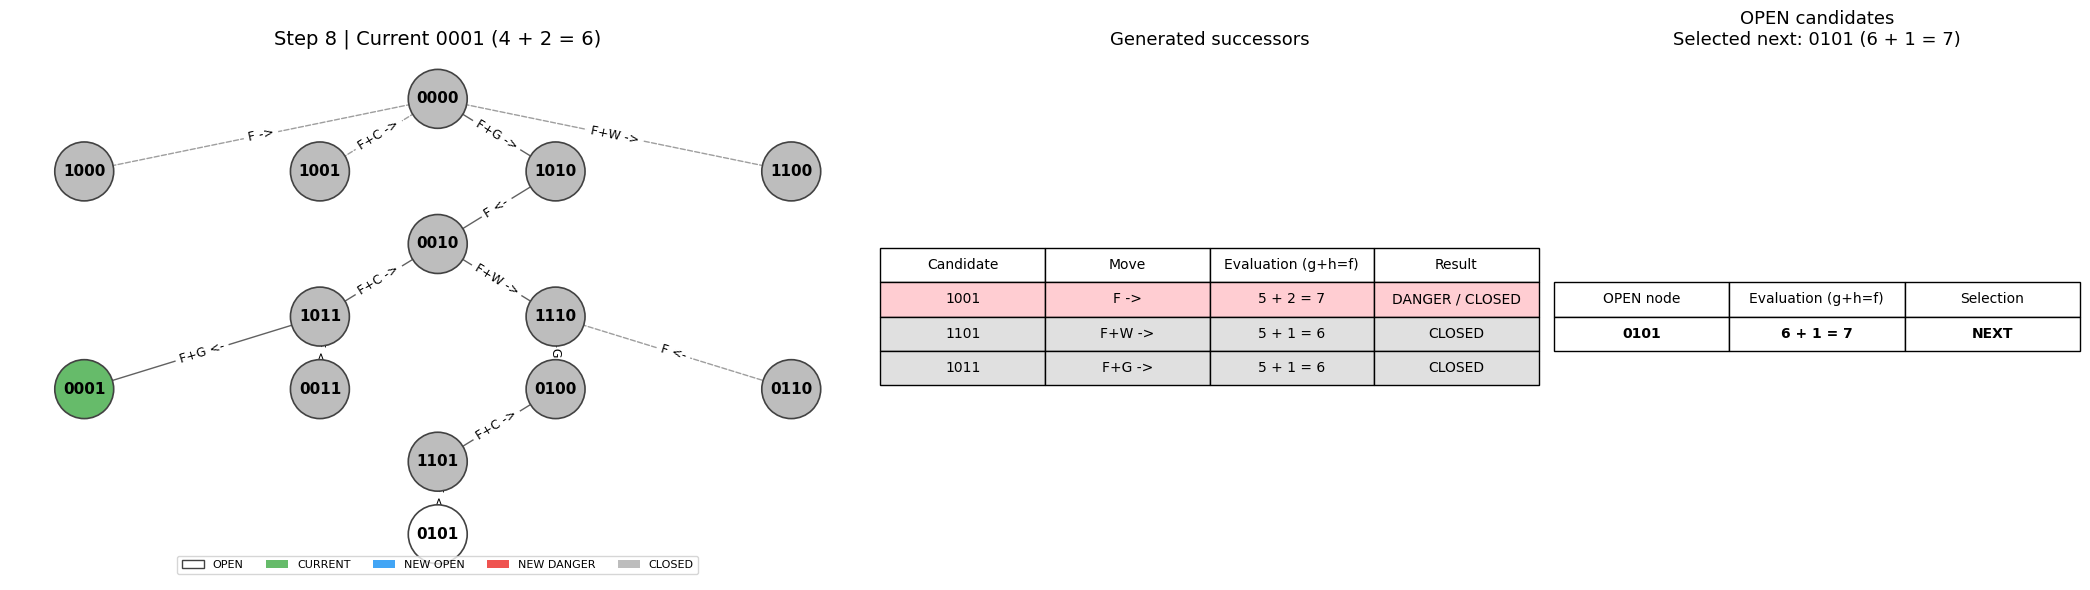

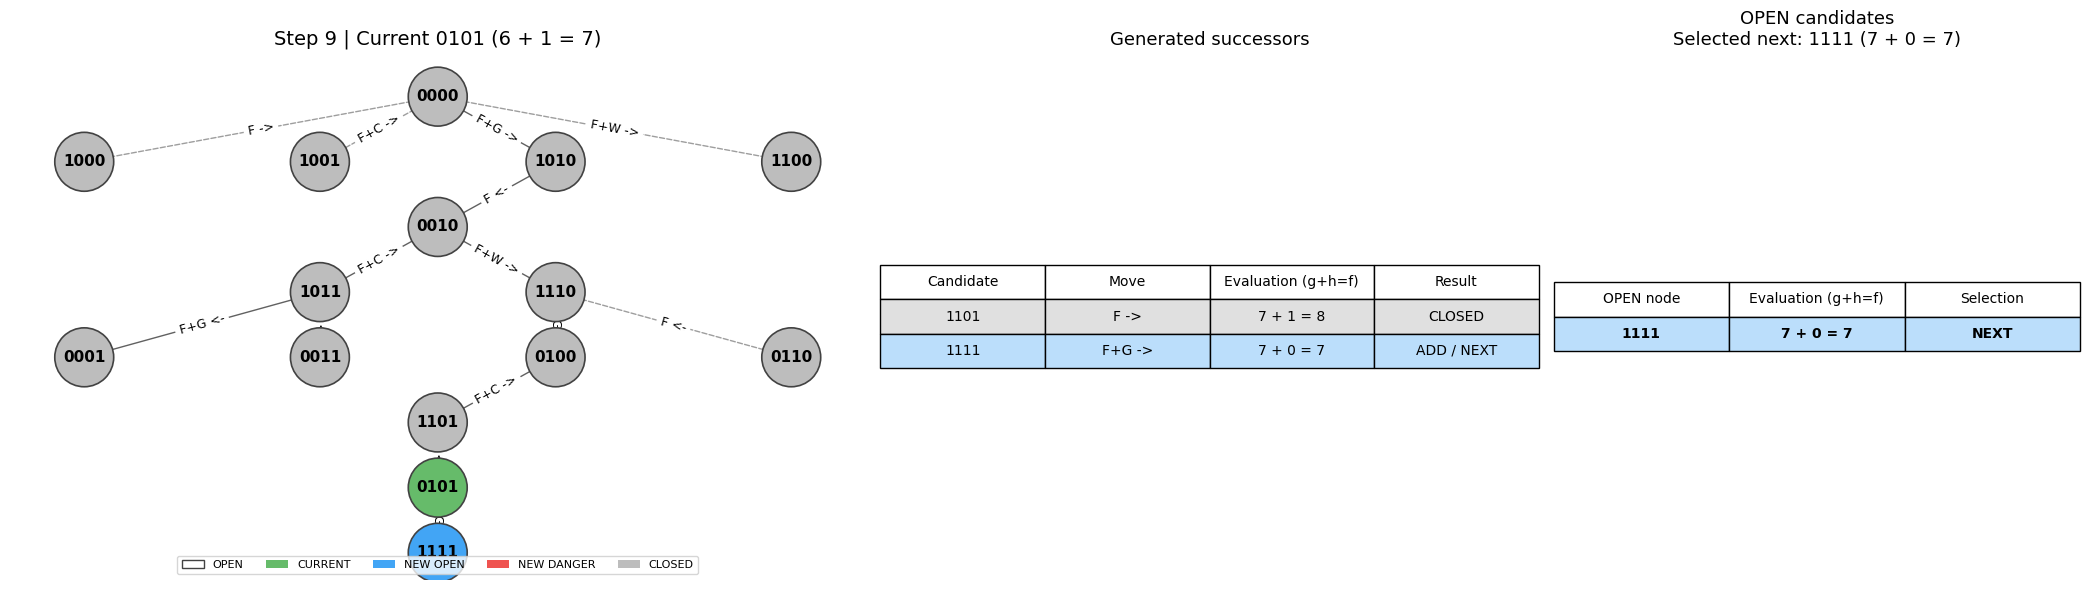

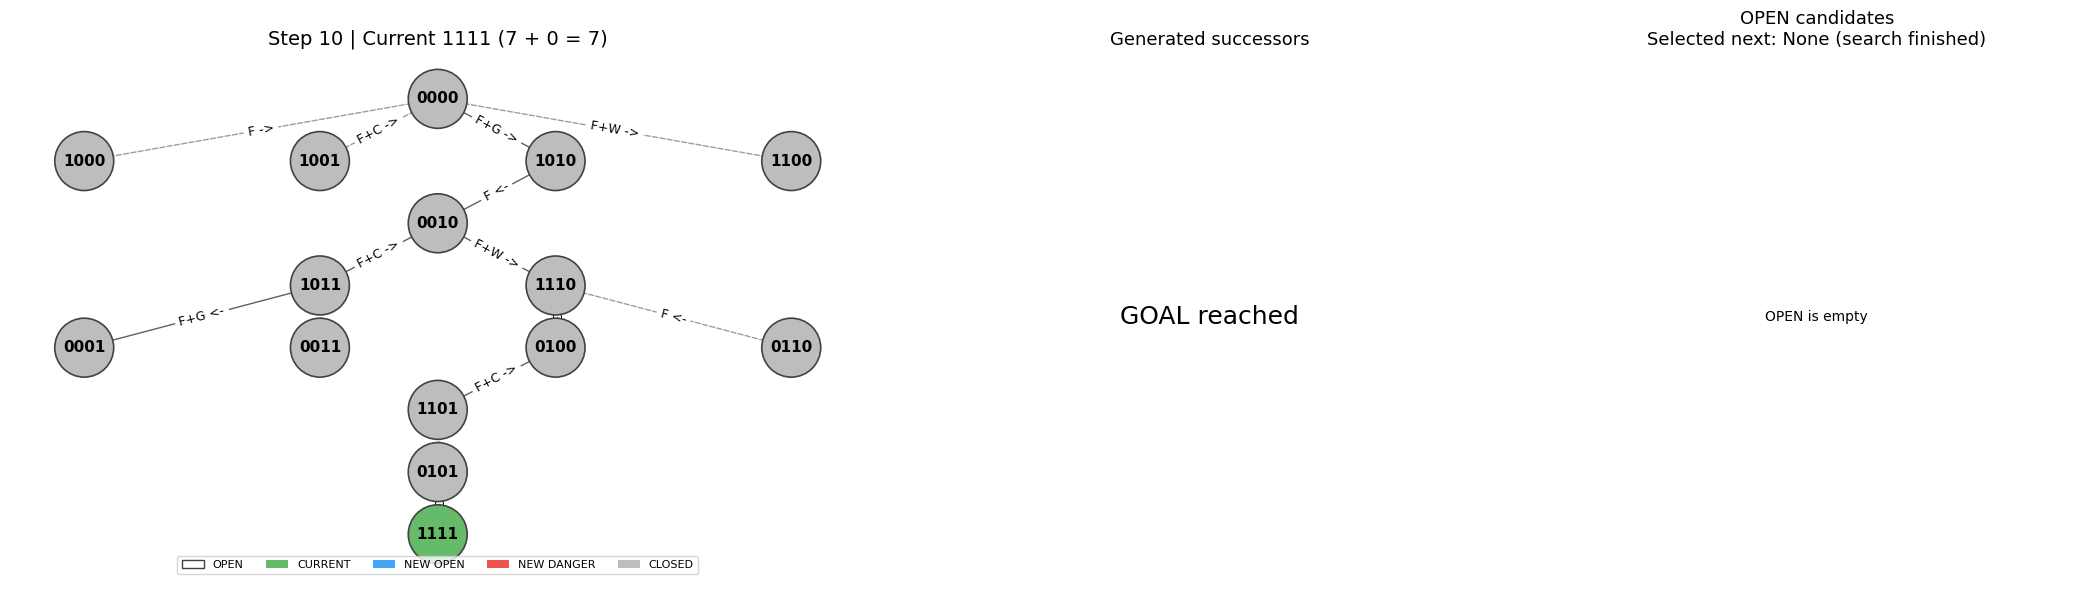

A* 탐색 완료: 10단계, 최단 이동 7회

시작: 0000
1. 0000 -- 농부와 염소 -> --> 1010
2. 1010 -- 농부 혼자 <- --> 0010
3. 0010 -- 농부와 늑대 -> --> 1110
4. 1110 -- 농부와 염소 <- --> 0100
5. 0100 -- 농부와 양배추 -> --> 1101
6. 1101 -- 농부 혼자 <- --> 0101
7. 0101 -- 농부와 염소 -> --> 1111
도착: 1111


In [18]:
def tree_positions(parent_map):
    depths = {START: 0}

    def get_depth(node):
        if node not in depths:
            depths[node] = get_depth(parent_map[node]) + 1
        return depths[node]

    for node in parent_map:
        get_depth(node)

    levels = {}
    for node, depth in depths.items():
        levels.setdefault(depth, []).append(node)

    positions = {}
    for depth, nodes in levels.items():
        nodes.sort()
        center = (len(nodes) - 1) / 2
        for index, node in enumerate(nodes):
            positions[node] = ((index - center) * 2.2, -depth * 1.5)
    return positions


legend_items = [
    Patch(facecolor="#ffffff", edgecolor="#424242", label="OPEN"),
    Patch(facecolor="#66bb6a", label="CURRENT"),
    Patch(facecolor="#42a5f5", label="NEW OPEN"),
    Patch(facecolor="#ef5350", label="NEW DANGER"),
    Patch(facecolor="#bdbdbd", label="CLOSED"),
]


def draw_snapshot(snapshot):
    graph = nx.DiGraph()
    graph.add_node(START)
    for source, target, label in snapshot["tree_edges"]:
        graph.add_edge(source, target, label=label)
    for source, target, label in snapshot["danger_edges"]:
        graph.add_edge(source, target, label=label)

    snapshot_parents = {START: None}
    for source, target, _ in snapshot["tree_edges"]:
        snapshot_parents[target] = source
    for source, target, _ in snapshot["danger_edges"]:
        if target not in snapshot_parents:
            snapshot_parents[target] = source
    positions = tree_positions(snapshot_parents)

    current = snapshot["current"]
    next_node = snapshot["next"]
    node_colors = []
    for node in graph.nodes:
        if node == current:
            node_colors.append("#66bb6a")
        elif node in snapshot["new_danger"]:
            node_colors.append("#ef5350")
        elif node in snapshot["new_open"]:
            node_colors.append("#42a5f5")
        elif node in snapshot["open"]:
            node_colors.append("#ffffff")
        else:
            node_colors.append("#bdbdbd")

    fig, (ax_graph, ax_successors, ax_open) = plt.subplots(
        1, 3, figsize=(21, 6), gridspec_kw={"width_ratios": [1.3, 1, 0.8]}
    )
    visible_positions = {node: positions[node] for node in graph.nodes}
    nx.draw_networkx_nodes(
        graph,
        pos=visible_positions,
        node_color=node_colors,
        node_size=1800,
        edgecolors="#424242",
        linewidths=1.2,
        ax=ax_graph,
    )
    nx.draw_networkx_labels(
        graph,
        pos=visible_positions,
        labels={node: state_text(node) for node in graph.nodes},
        font_size=11,
        font_weight="bold",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["tree_edges"]
            if target not in snapshot["new_open"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#616161",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["tree_edges"]
            if target in snapshot["new_open"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#42a5f5",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["danger_edges"]
            if target not in snapshot["new_danger"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#9e9e9e",
        style="dashed",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["danger_edges"]
            if target in snapshot["new_danger"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#ef5350",
        style="dashed",
        ax=ax_graph,
    )
    nx.draw_networkx_edge_labels(
        graph,
        pos=visible_positions,
        edge_labels=nx.get_edge_attributes(graph, "label"),
        font_size=9,
        ax=ax_graph,
    )
    current_g = snapshot["g_score"][current]
    current_h = heuristic(current)
    ax_graph.set_title(
        f"Step {snapshot['step']} | Current {state_text(current)} "
        f"({current_g} + {current_h} = {current_g + current_h})",
        fontsize=14,
    )
    ax_graph.legend(handles=legend_items, loc="lower center", ncol=5, fontsize=8)
    ax_graph.axis("off")

    columns = ["Candidate", "Move", "Evaluation (g+h=f)", "Result"]
    rows = [
        [
            state_text(row["state"]),
            row["move"],
            f"{row['g']} + {row['h']} = {row['f']}",
            row["result"],
        ]
        for row in snapshot["candidates"]
    ]
    ax_successors.axis("off")
    if rows:
        table = ax_successors.table(
            cellText=rows, colLabels=columns, cellLoc="center", loc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.8)
        for row_index, row in enumerate(snapshot["candidates"], start=1):
            if "DANGER" in row["result"]:
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#ffcdd2")
            elif row["result"].startswith("ADD"):
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#bbdefb")
            elif row["result"] == "CLOSED":
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#e0e0e0")
    else:
        ax_successors.text(
            0.5, 0.5, "GOAL reached", ha="center", va="center", fontsize=18
        )

    if next_node is None:
        next_text = "None (search finished)"
    else:
        next_g = snapshot["g_score"][next_node]
        next_h = heuristic(next_node)
        next_text = (
            f"{state_text(next_node)} "
            f"({next_g} + {next_h} = {next_g + next_h})"
        )
    ax_successors.set_title("Generated successors", fontsize=13)

    open_columns = ["OPEN node", "Evaluation (g+h=f)", "Selection"]
    open_rows = [
        [
            state_text(row["state"]),
            f"{row['g']} + {row['h']} = {row['f']}",
            "NEXT" if row["selected"] else "OPEN",
        ]
        for row in snapshot["open_candidates"]
    ]
    ax_open.axis("off")
    if open_rows:
        open_table = ax_open.table(
            cellText=open_rows,
            colLabels=open_columns,
            cellLoc="center",
            loc="center",
        )
        open_table.auto_set_font_size(False)
        open_table.set_fontsize(10)
        open_table.scale(1, 1.8)
        for row_index, row in enumerate(snapshot["open_candidates"], start=1):
            if row["state"] in snapshot["new_open"]:
                for column_index in range(len(open_columns)):
                    open_table[(row_index, column_index)].set_facecolor("#bbdefb")
            if row["selected"]:
                for column_index in range(len(open_columns)):
                    open_table[(row_index, column_index)].get_text().set_weight("bold")
    else:
        ax_open.text(0.5, 0.5, "OPEN is empty", ha="center", va="center")
    ax_open.set_title(f"OPEN candidates\nSelected next: {next_text}", fontsize=13)
    plt.tight_layout()
    plt.show()


path, actions, parents, edge_labels, snapshots = astar(
    START, GOAL, on_step=draw_snapshot
)
print(f"A* 탐색 완료: {len(snapshots)}단계, 최단 이동 {len(path) - 1}회\n")
print_solution(path, actions)

## 결론

A* 탐색으로 찾은 최단 해는 7번의 이동입니다.

1. 염소를 오른쪽으로 옮긴다.
2. 농부가 혼자 왼쪽으로 돌아온다.
3. 늑대를 오른쪽으로 옮긴다.
4. 염소를 왼쪽으로 데려온다.
5. 양배추를 오른쪽으로 옮긴다.
6. 농부가 혼자 왼쪽으로 돌아온다.
7. 염소를 오른쪽으로 옮긴다.

3번과 5번의 늑대/양배추 이동 순서는 서로 바뀌어도 안전한 최단 해가 됩니다.